<a href="https://colab.research.google.com/github/SiddhantUke/LangGraph/blob/main/Gemini_testing_Successfull_OPEN_SOURCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.1/125.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.0/570.0 kB 17.6 MB/s eta 0:00:00
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.5.5
    Uninstalling langchain-core-1.5.5:
      Successfully uninstalled langchain-core-1.5.5


In [1]:
import os

from dotenv import load_dotenv
from typing import TypedDict

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

load_dotenv()

False

In [2]:
!pip install langchain_community

In [7]:
from langchain_community.llms import HuggingFaceEndpoint

hf = HuggingFaceEndpoint(
    repo_id="mistralai/Mistral-7B-v0.1",
    model_kwargs={"temperature":0.1, "max_length":500})


/tmp/ipykernel_6931/742316070.py:3: LangChainDeprecationWarning: The class `HuggingFaceEndpoint` was deprecated in LangChain 0.0.37 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEndpoint``.
  hf = HuggingFaceEndpoint(


ValidationError: 1 validation error for HuggingFaceEndpoint
  Value error, Parameters {'temperature'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter. [type=value_error, input_value={'repo_id': 'mistralai/Mi...0.1, 'max_length': 500}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error

In [8]:
# llm = ChatOpenAI(
#     model="kimi-k3",
#     api_key=os.getenv("MOONSHOT_API_KEY"),
#     base_url="https://api.moonshot.cn/v1"
# )




from langchain_community.llms import HuggingFaceEndpoint
hf = HuggingFaceEndpoint(
    repo_id="LiquidAI/LFM2.5-2.6B-GGUF",
    model_kwargs={"temperature":0.1, "max_length":500})

ValidationError: 1 validation error for HuggingFaceEndpoint
  Value error, Parameters {'temperature'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter. [type=value_error, input_value={'repo_id': 'LiquidAI/LFM...0.1, 'max_length': 500}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error

In [ ]:
import os

from dotenv import load_dotenv
from typing import TypedDict

from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END

load_dotenv()


# -------------------------
# 1. Create Kimi K3
# -------------------------

llm = ChatOpenAI(
    model="kimi-k3",
    api_key=os.getenv("MOONSHOT_API_KEY"),
    base_url="https://api.moonshot.cn/v1"
)


# -------------------------
# 2. Define State
# -------------------------

class State(TypedDict):
    question: str
    answer: str


# -------------------------
# 3. Define Node
# -------------------------

def chatbot(state: State):

    response = llm.invoke(
        state["question"]
    )

    return {
        "answer": response.content
    }


# -------------------------
# 4. Build Graph
# -------------------------

graph_builder = StateGraph(State)

graph_builder.add_node(
    "chatbot",
    chatbot
)

graph_builder.add_edge(
    START,
    "chatbot"
)

graph_builder.add_edge(
    "chatbot",
    END
)


# -------------------------
# 5. Compile
# -------------------------

graph = graph_builder.compile()


# -------------------------
# 6. Invoke
# -------------------------

result = graph.invoke({
    "question": "What is a vector database?",
    "answer": ""
})

print(result["answer"])

In [9]:
!pip install -U transformers accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 88.0 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.15.0
    Uninstalling transformers-5.15.0:
      Successfully uninstalled transformers-5.15.0


In [10]:
model_id = "LiquidAI/LFM2.5-2.6B-GGUF"

In [9]:
!pip install langchain-deepseek langgraph python-dotenv

In [10]:
import os

from dotenv import load_dotenv
from typing import TypedDict

from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END

load_dotenv()


False

In [14]:
import os
import requests

from dotenv import load_dotenv
from typing import TypedDict

from langgraph.graph import StateGraph, START, END

load_dotenv()


# -------------------------
# 1. DeepSeek API
# -------------------------

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")

def call_deepseek(question: str):

    url = "https://api.deepseek.com/chat/completions"

    headers = {
        "Authorization": f"Bearer {DEEPSEEK_API_KEY}",
        "Content-Type": "application/json"
    }

    data = {
        "model": "deepseek-chat",
        "messages": [
            {
                "role": "user",
                "content": question
            }
        ]
    }

    response = requests.post(
        url,
        headers=headers,
        json=data
    )

    response.raise_for_status()

    result = response.json()

    return result["choices"][0]["message"]["content"]

In [15]:
# -------------------------
# 2. Define State
# -------------------------

class State(TypedDict):
    question: str
    answer: str


# -------------------------
# 3. Define Node
# -------------------------

def chatbot(state: State):

    answer = call_deepseek(
        state["question"]
    )

    return {
        "answer": answer
    }


# -------------------------
# 4. Build Graph
# -------------------------

graph_builder = StateGraph(State)

graph_builder.add_node(
    "chatbot",
    chatbot
)

graph_builder.add_edge(
    START,
    "chatbot"
)

graph_builder.add_edge(
    "chatbot",
    END
)


# -------------------------
# 5. Compile
# -------------------------

graph = graph_builder.compile()

In [19]:
import os
from google.colab import userdata

os.environ["DEEPSEEK_API_KEY"] = userdata.get("DEEPSEEK_API_KEY")

In [20]:
print("API key exists:", os.getenv("DEEPSEEK_API_KEY") is not None)
print("API key length:", len(os.getenv("DEEPSEEK_API_KEY", "")))

API key exists: True
API key length: 35


In [22]:
import os
from google.colab import userdata

os.environ["DEEPSEEK_API_KEY"] = userdata.get("DEEPSEEK_API_KEY")

print("Key loaded:", bool(os.environ.get("DEEPSEEK_API_KEY")))
print("Key length:", len(os.environ.get("DEEPSEEK_API_KEY", "")))

Key loaded: True
Key length: 35


In [23]:
import requests
import os

api_key = os.environ["DEEPSEEK_API_KEY"]

response = requests.post(
    "https://api.deepseek.com/chat/completions",
    headers={
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    },
    json={
        "model": "deepseek-chat",
        "messages": [
            {
                "role": "user",
                "content": "Say hello"
            }
        ]
    }
)

print("Status:", response.status_code)
print("Response:", response.text)

Status: 402
Response: {"error":{"message":"Insufficient Balance","type":"unknown_error","param":null,"code":"invalid_request_error"}}


In [21]:
# -------------------------
# 6. Invoke
# -------------------------

result = graph.invoke({
    "question": "What is a vector database?",
    "answer": ""
})


print(result["answer"])

HTTPError: 401 Client Error: Unauthorized for url: https://api.deepseek.com/chat/completions

In [1]:
!pip install -U google-genai langgraph

In [26]:
import os
from google.colab import userdata

os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")

print("Key loaded:", bool(os.getenv("GEMINI_API_KEY")))

Key loaded: True


In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END


class Stateg(TypedDict):
    question: str
    answer: str


def chatbot(state: State):

    response = client.models.generate_content(
        model="gemini-3.7-flash",
        contents=state["question"]
    )

    return {
        "answer": response.text
    }

In [3]:
!pip install -U google-genai

In [3]:
import os
from google import genai
from google.colab import userdata

os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")

client = genai.Client(
    api_key=os.environ["GEMINI_API_KEY"]
)

print("Gemini client created successfully")

Gemini client created successfully


In [1]:
import os
from google.colab import userdata

os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")

print("Key loaded:", bool(os.environ.get("GEMINI_API_KEY")))
print("Key length:", len(os.environ.get("GEMINI_API_KEY", "")))

Key loaded: True
Key length: 53


In [12]:
response = client.models.generate_content(
    model="gemini-3.6-flash",
    contents="What is a vector database?"
)

print(response)

sdk_http_response=HttpResponse(
  headers=<dict len=11>
) candidates=[Candidate(
  content=Content(
    parts=[
      Part(
        text="""At its simplest, a **vector database** is a specialized database designed to store, manage, and search **unstructured data** (like text, images, audio, and video) based on its **meaning or context**, rather than exact keyword matches.

While traditional databases excel at finding exact matches (e.g., "Find customer with ID 1234"), vector databases excel at finding **similarities** (e.g., "Find images that look like this cat" or "Find documents that talk about climate change").

---

### The Secret Sauce: What is a Vector Embedding?

To understand a vector database, you first need to understand **vectors (or embeddings)**.

AI models (like ChatGPT or Midjourney) convert complex human data into long lists of numbers called **vector embeddings**. These numbers represent the *semantic meaning* of the data as coordinates in a multi-dimensional space.

*

In [7]:
graph_builder = StateGraph(State)

graph_builder.add_node(
    "chatbot",
    chatbot
)

graph_builder.add_edge(
    START,
    "chatbot"
)

graph_builder.add_edge(
    "chatbot",
    END
)


NameError: name 'StateGraph' is not defined

In [28]:
def chatbot(state: State):

    response = client.models.generate_content(
        model="gemini-3.7-flash",
        contents=state["question"]
    )

    return {
        "answer": response.text
    }



In [8]:
import os

from google import genai
from google.colab import userdata

from typing import TypedDict
from langgraph.graph import StateGraph, START, END


# -------------------------
# 1. Gemini API
# -------------------------

os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")

client = genai.Client(
    api_key=os.environ["GEMINI_API_KEY"]
)


# -------------------------
# 2. Define State
# -------------------------

class State(TypedDict):
    question: str
    answer: str


# -------------------------
# 3. Define Node
# -------------------------

def chatbot(state: State):

    response = client.models.generate_content(
        model="gemini-3.6-flash",
        contents=state["question"]
    )

    return {
        "answer": response.text
    }


# -------------------------
# 4. Build Graph
# -------------------------

graph_builder = StateGraph(State)

graph_builder.add_node(
    "chatbot",
    chatbot
)

graph_builder.add_edge(
    START,
    "chatbot"
)

graph_builder.add_edge(
    "chatbot",
    END
)




In [9]:
# -------------------------
# 5. Compile
# -------------------------

graph = graph_builder.compile()

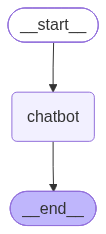

In [10]:
graph

In [11]:
# -------------------------
# 6. Invoke
# -------------------------

result = graph.invoke({
    "question": "What is a vector database?",
    "answer": ""
})

print(result["answer"])

A **vector database** is a specialized type of database designed to store, manage, and search **high-dimensional vectors**. 

Unlike traditional databases that search for exact matches (like matching a specific keyword or user ID), a vector database searches for **similarity**—finding items that are "conceptually close" to one another in meaning.

Vector databases have become extremely popular recently because they serve as the "long-term memory" for Artificial Intelligence (AI) and Large Language Models (LLMs) like ChatGPT.

---

### Key Concepts: How It Works

To understand a vector database, you need to understand three core concepts:

#### 1. Vector Embeddings (Translating Data into Math)
AI models process real-world unstructured data (text, images, audio, video) by converting it into a list of numbers called a **vector embedding**. 
* For example, an AI might turn the word *"Dog"* into a list of numbers like `[0.12, -0.85, 0.43, ...]`.
* Words or images with similar meanings end u